<a href="https://colab.research.google.com/github/poppoppulanaresh-max/CAPSTONE-PROJECTS-PYTHON/blob/main/Revenue_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT:**

We have the data of different restaurant and we want to predict how much revenue a restauramt will generate.

Build a Machine Learning Algorithm that can predict the revenue of restaurant.

Type of Probelem:

Revenue is a number(continous value)

Regression Problem.

In [ ]:
#Importing the libraires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the Dataset
df=pd.read_csv('/content/revenue_prediction (1).csv')
df

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715
...,...,...,...,...,...,...,...,...
95,196,Wetzel'sPretzels,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,197,LaMadeleineCountryFrenchCafe,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,198,Giordano's,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,199,IslandsFineBurgers&Drinks,Yes,Sports Bar,Pune,25,2.1,2344689


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            100 non-null    int64  
 1   Name          100 non-null    object 
 2   Franchise     100 non-null    object 
 3   Category      100 non-null    object 
 4   City          100 non-null    object 
 5   No_Of_Item    100 non-null    int64  
 6   Order_Placed  100 non-null    float64
 7   Revenue       100 non-null    int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB


In [ ]:
df.describe()

,Id,No_Of_Item,Order_Placed,Revenue
count,100.000000,100.000000,100.000000,1.000000e+02
mean,150.500000,49.080000,4.086000,4.395161e+06
std,29.011492,22.370923,2.055101,2.659932e+06
min,101.000000,18.000000,1.000000,8.498700e+05
25%,125.750000,34.750000,2.750000,2.688328e+06
50%,150.500000,45.000000,3.650000,3.911401e+06
75%,175.250000,57.250000,5.100000,5.330084e+06
max,200.000000,126.000000,13.000000,1.969694e+07


In [ ]:
df.shape

(100, 8)

In [ ]:
'''Data cleaning'''
#Check the Null Values
df.isnull().sum()

,0
Id,0
Name,0
Franchise,0
Category,0
City,0
No_Of_Item,0
Order_Placed,0
Revenue,0


In [ ]:
#Check for the Duplicate Records
df.duplicated().sum()

np.int64(0)

In [ ]:
#Drop Unnecessary Column
df.drop(['Id','Name'],axis=1,inplace=True)

In [ ]:
df

,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,Yes,Mexican,Bengaluru,55,5.5,5953753
1,No,Varied Menu,Gurugram,72,6.8,7223131
2,Yes,Chicken,Pune,25,1.9,2555379
3,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,Yes,Pizza,Noida,48,4.2,4816715
...,...,...,...,...,...,...
95,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,Yes,Sports Bar,Pune,25,2.1,2344689


In [ ]:
#Convert Categorical Column to Numerical
from sklearn.preprocessing import LabelEncoder

In [ ]:
le =LabelEncoder()

In [ ]:
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=le.fit_transform(df[i])

In [ ]:
df

,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,1,12,0,55,5.5,5953753
1,0,19,1,72,6.8,7223131
2,1,5,4,25,1.9,2555379
3,1,11,2,18,2.5,2175511
4,1,13,3,48,4.2,4816715
...,...,...,...,...,...,...
95,0,11,0,19,1.1,1270499
96,1,19,0,75,6.3,6412623
97,1,19,1,77,6.2,6694797
98,1,17,4,25,2.1,2344689


In [ ]:
#Split the data into dependent and independent variable
x=df.iloc[:,:-1]
y=df['Revenue']

In [ ]:
x

,Franchise,Category,City,No_Of_Item,Order_Placed
0,1,12,0,55,5.5
1,0,19,1,72,6.8
2,1,5,4,25,1.9
3,1,11,2,18,2.5
4,1,13,3,48,4.2
...,...,...,...,...,...
95,0,11,0,19,1.1
96,1,19,0,75,6.3
97,1,19,1,77,6.2
98,1,17,4,25,2.1


In [ ]:
y

,Revenue
0,5953753
1,7223131
2,2555379
3,2175511
4,4816715
...,...
95,1270499
96,6412623
97,6694797
98,2344689


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

# Model Building

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr=LinearRegression()

In [ ]:
#Train the Model
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
#Test the Model
y_pred=lr.predict(x_test)

In [ ]:
y_pred

array([6666479.57324263, 5639644.54872309, 3805536.39463167,
       4193324.18078208, 4343130.14047885, 3771286.28284555,
       3975231.17369166, 3538465.19057696, 4008270.62952065,
       6564461.36756485, 5475587.89962776, 3049610.70004873,
       2810473.9006414 , 2279966.85189423, 3582880.67553956,
       4520150.55828419, 5132586.00030909, 1439624.56657968,
       1771028.10021913, 2139029.64016056])

In [ ]:
#Evaluate the model
from sklearn.metrics import r2_score

In [ ]:
r2_score(y_test,y_pred)

0.8639287715046499

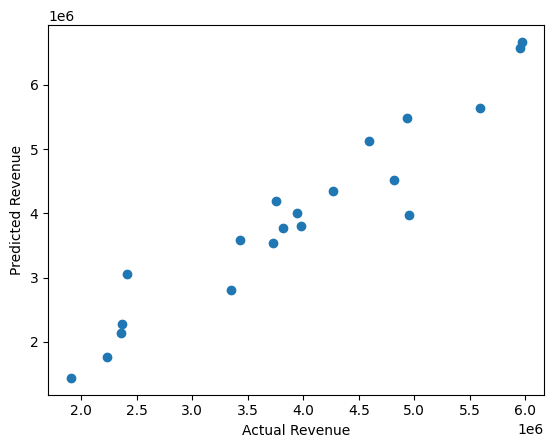

In [ ]:
#Visulise the Prediction
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.show()

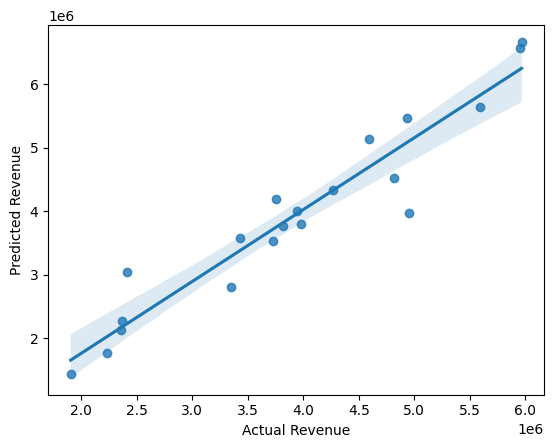

In [ ]:
#Visulise the Prediction
sns.regplot(x=y_test,y=y_pred)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.show()

Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Decision Tree R2 Score: {r2_dt}")

Decision Tree R2 Score: 0.4121420385038497


### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest R2 Score: {r2_rf}")

Random Forest R2 Score: 0.7929458058742888


### Visualizing Predictions for Decision Tree

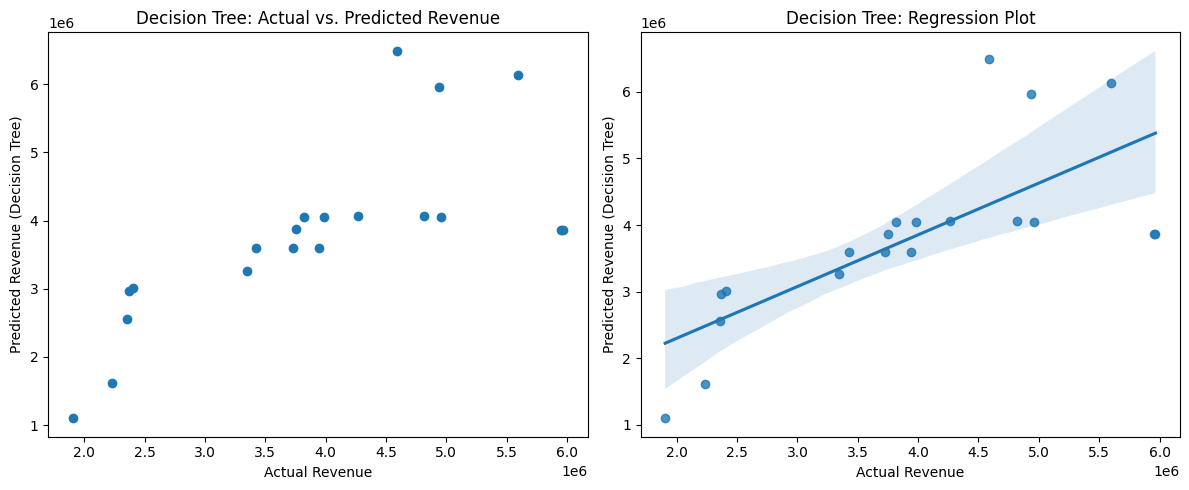

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_dt)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue (Decision Tree)')
plt.title('Decision Tree: Actual vs. Predicted Revenue')

plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_pred_dt)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue (Decision Tree)')
plt.title('Decision Tree: Regression Plot')

plt.tight_layout()
plt.show()

### Visualizing Predictions for Random Forest

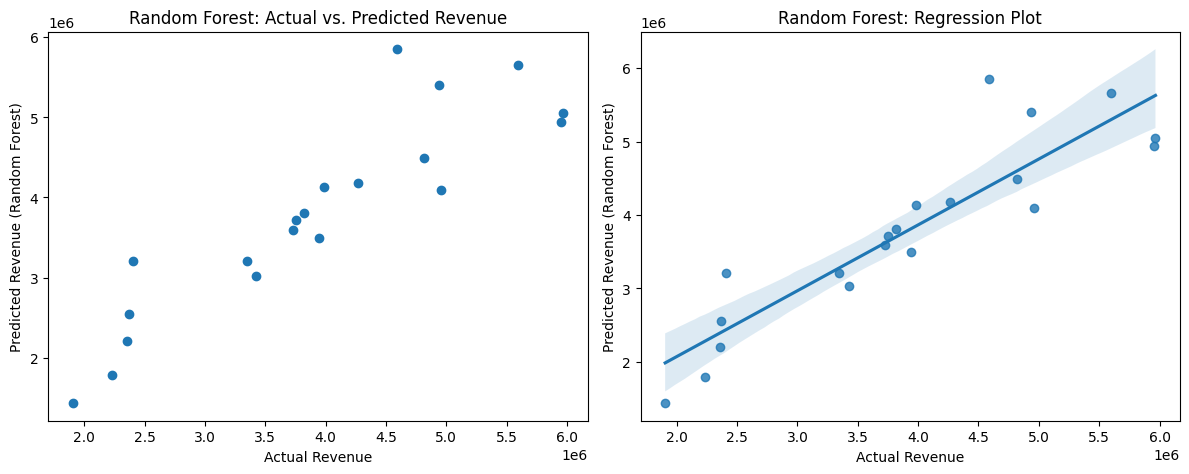

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue (Random Forest)')
plt.title('Random Forest: Actual vs. Predicted Revenue')

plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_pred_rf)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue (Random Forest)')
plt.title('Random Forest: Regression Plot')

plt.tight_layout()
plt.show()